# Thesis 2024 - 2025
## UGBS
### Isil Oral

* Project on green gentrification in Vienna through social status index, green spaces, blue areas, and housing prices 

## Part 3 - Social Housing in Vienna

In [1]:
from shapely.geometry import box, Point, LineString, Polygon, MultiPolygon
from shapely.ops import unary_union
import geopandas as gpd
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling
import osmnx as ox  
import contextily as ctx
from geopy.geocoders import Nominatim  
from geopy.extra.rate_limiter import RateLimiter
import os
!pip install h3
import h3
import matplotlib.patches as mpatches

In [2]:
# Get the current working directory
current_path = os.getcwd()

# Define relative paths for data, output, and helper functions
data_in = os.path.join(current_path, "data")       # Folder with input data
output = os.path.join(current_path, "output")      # Folder for saving results
df_dir = os.path.join(current_path, "dataframes")

In [3]:
# Load any dataframe from that folder
admin_city = gpd.read_file(os.path.join(df_dir, "admin_city_vienna.geojson"))
ugbs_socioecon_census = pd.read_csv(os.path.join(df_dir, "ugbs_socioecon_census.csv"))
urban_green_spaces =gpd.read_file(os.path.join(df_dir, "urban_green_spaces.geojson"))
urban_blue_spaces = gpd.read_file(os.path.join(df_dir, "urban_blue_spaces.geojson"))
apt_features_final = pd.read_csv(os.path.join(df_dir, 'apt_features_final_census.csv'))

Skipping field ways: unsupported OGR type: 1


In [4]:
buildings_csv = 'data/gemeindebaubeschreibungen.csv'
buildings = pd.read_csv(buildings_csv, encoding='latin1', delimiter=';')

In [5]:
def clean_address(row):
    try:
        # Split into two parts: "1100 Wien" and the repeated street name
        parts = row.split(",", 1)
        if len(parts) != 2:
            return row  # if format is unexpected, return as-is

        prefix = parts[0].strip()
        street = parts[1].strip().split()  # split into words

        # Keep only the first occurrence of each word (preserving order)
        seen = set()
        deduped_street = []
        for word in street:
            if word not in seen:
                seen.add(word)
                deduped_street.append(word)

        return f"{prefix}, {' '.join(deduped_street)}"
    except Exception as e:
        print(f"Cleaning failed for: {row} — {e}")
        return row


In [6]:
buildings["clean_address"] = buildings["Adresse"].apply(clean_address)
buildings.head(3)

,Hofname,Adresse,Baujahr von,Baujahr bis,Baujahr um,Architekt,Kunst am Bau,Letzte Sanierung von,Letzte Sanierung bis,Wohnungen,Lokale,PDF-Download,clean_address
0,Per-Albin-Hansson-Siedlung-Ost,"1100 Wien, Jura-Soyfer-Gasse Jura-Soyfer-Gasse",1970.0,1974.0,NaN,"Hermann Kutschera, Peter Payer, Oskar Payer",ja,NaN,NaN,4289,25,https://www.wwpipe.at/web-portal/complex-descr...,"1100 Wien, Jura-Soyfer-Gasse"
1,Rudolf-Hitzinger-Hof,"1210 Wien, Leopoldauer Straße Leopoldauer Straße",1969.0,1971.0,NaN,"Friedrich Lang, Ernst Plojhar",nein,NaN,NaN,284,7,https://www.wwpipe.at/web-portal/complex-descr...,"1210 Wien, Leopoldauer Straße"
2,Großfeldsiedlung,"1210 Wien, St.-Michael-Gasse St.-Michael-Gasse",1966.0,1971.0,NaN,"Peter Payer, Heinrich Matha, Oskar Payer, Matt...",ja,NaN,NaN,5525,41,https://www.wwpipe.at/web-portal/complex-descr...,"1210 Wien, St.-Michael-Gasse"


In [7]:
social_housing = buildings[['Hofname','clean_address' , 'Wohnungen', 'Lokale']]
type(social_housing)
social_housing.to_csv("dataframes/social_housing.csv", index=False)

In [8]:
print(len(social_housing))
social_housing.head(3)

1636


,Hofname,clean_address,Wohnungen,Lokale
0,Per-Albin-Hansson-Siedlung-Ost,"1100 Wien, Jura-Soyfer-Gasse",4289,25
1,Rudolf-Hitzinger-Hof,"1210 Wien, Leopoldauer Straße",284,7
2,Großfeldsiedlung,"1210 Wien, St.-Michael-Gasse",5525,41


Number of total buildings: 29638


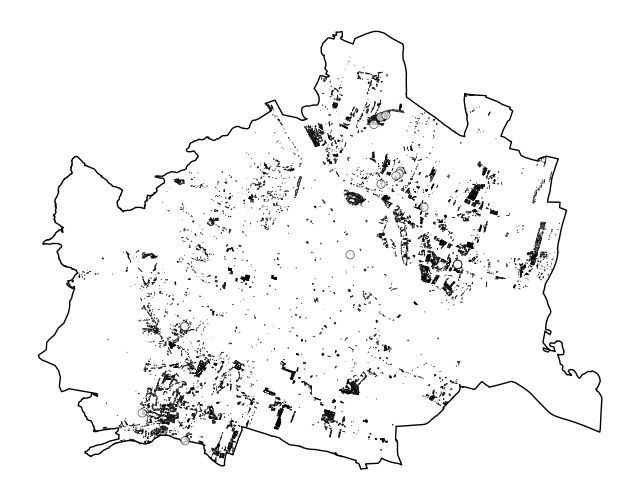

In [9]:
# Define the polygon for the admin boundary of the 1st district of Bp.
admin_poly = admin_city.geometry.values[0]

# Download building footprints within the administrative boundary
residential = ox.features_from_polygon(admin_poly, tags = {"building": ["apartment", 'terrace', "detached", "annexe", "house", "residential", "semidetached_house"]})

print("Number of total buildings:", len(residential))

# Create a plot to visualize the admin boundary and building footprints
f, ax = plt.subplots(1, 1, figsize=(8, 8))

# Plot the administrative boundary
admin_city.plot(ax=ax, color='none', edgecolor='k')

# Plot the building footprints
residential.plot(ax=ax, 
                cmap = 'Greys', 
                edgecolor='black', 
                alpha=0.7, 
                linewidth = 0.5)

# Customize the plot
ax.axis('off')
plt.show()

In [10]:
print(social_housing.dtypes)

Hofname          object
clean_address    object
Wohnungen         int64
Lokale            int64
dtype: object


In [11]:
# If social_housing is a filtered view, make a safe copy
social_housing_copy = social_housing.copy()

In [12]:
# Download only address-tagged nodes from OpenStreetMap for Vienna
tags = {"addr:street": True, "addr:housenumber": True}
osm_data = ox.features_from_place("Vienna, Austria", tags)

# Filter out rows with missing street or housenumber info
osm_addrs = osm_data[["addr:street", "addr:housenumber", "geometry"]].dropna()

# Ensure proper coordinate system
osm_addrs = osm_addrs.to_crs("EPSG:4326")

/opt/anaconda3/envs/geo/lib/python3.13/site-packages/osmnx/features.py:294: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = gdf_place["geometry"].unary_union


In [13]:
social_housing_copy["addr_key"] = social_housing_copy["clean_address"].str.lower().str.strip()
osm_addrs["addr_key"] = (
    osm_addrs["addr:street"].str.lower().str.strip() + " " +
    osm_addrs["addr:housenumber"].astype(str).str.strip()
)

In [14]:
#!pip install rapidfuzz

In [15]:
from rapidfuzz import process

# Build a dictionary: OSM addr_key → geometry
osm_lookup = dict(zip(osm_addrs["addr_key"], osm_addrs["geometry"]))

def get_best_match(addr):
    if pd.isna(addr):
        return None
    match, score, _ = process.extractOne(addr, list(osm_lookup.keys()))
    if score > 85:
        return osm_lookup[match]
    return None

# Apply matching
social_housing_copy["geometry"] = social_housing_copy["addr_key"].apply(get_best_match)

In [16]:
# Drop rows where no match found (no geometry)
social_housing_copy = social_housing_copy.dropna(subset=["geometry"])

# Convert to proper GeoDataFrame
social_housing_gdf = gpd.GeoDataFrame(social_housing_copy, geometry="geometry", crs="EPSG:4326")
print(len(social_housing_gdf))

1622


In [17]:
social_housing_gdf.to_file("dataframes/social_housing.geojson", driver="GeoJSON")

In [18]:
districts = gpd.read_file('data/vienna_districts.geojson') # districts data from GIS course hw2
census_boundaries = gpd.read_file('data/ZAEHLBEZIRKOGDPolygon.shp')
print(len(census_boundaries))

250


/var/folders/fg/tx5hq3917p5dxc674m9h_4500000gn/T/ipykernel_89070/1074487331.py:21: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


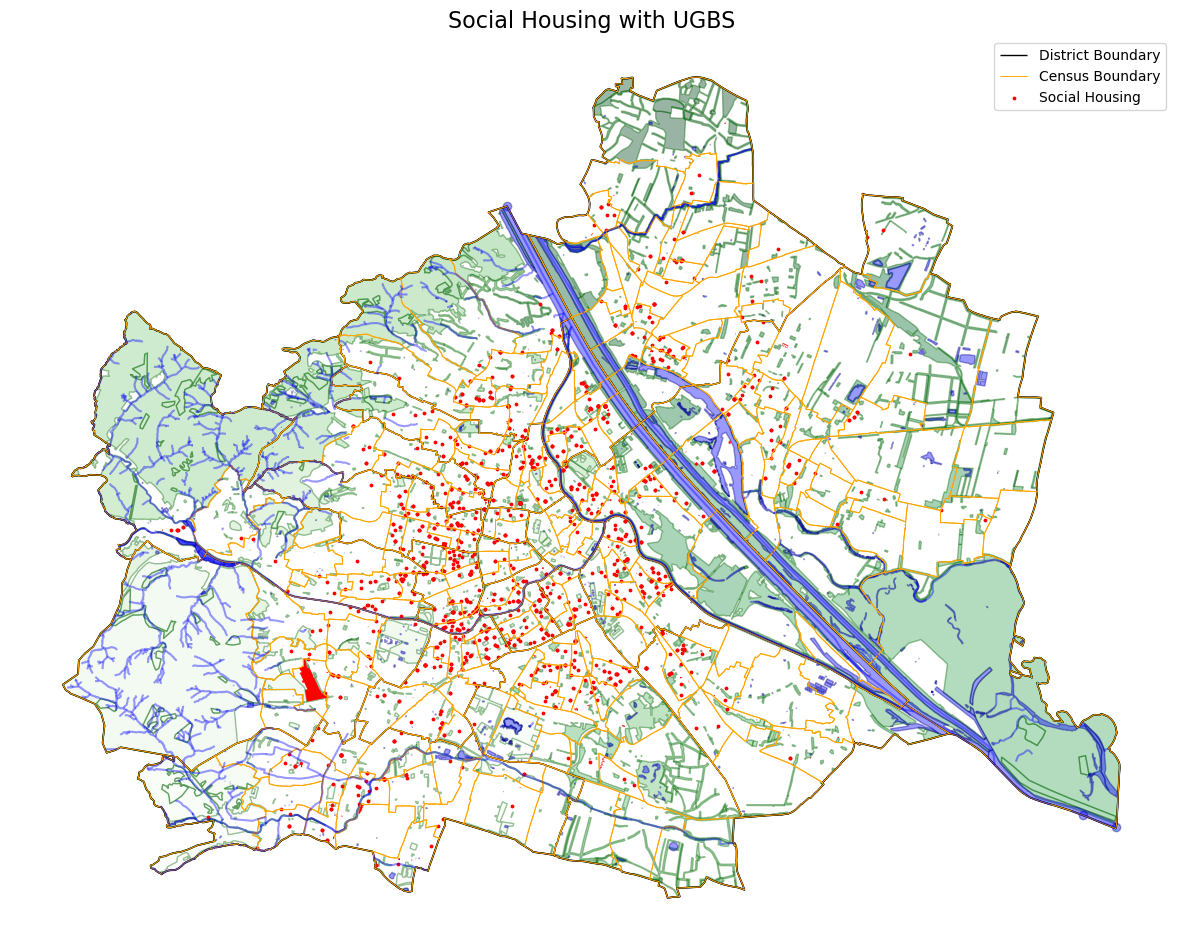

In [19]:
fig, ax = plt.subplots(figsize=(15, 15))

# Plot administrative and census boundaries
admin_city.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.2, label="Admin Boundary")
districts.boundary.plot(ax=ax, edgecolor='black', linewidth=1, label="District Boundary")
census_boundaries.boundary.plot(ax=ax, edgecolor='orange', linewidth=0.7, label="Census Boundary")

# Plot urban green/blue spaces (transparent overlays)
urban_green_spaces.plot(ax=ax, cmap='Greens', alpha=0.4, edgecolor='darkgreen')
urban_blue_spaces.plot(ax=ax, color='blue', alpha=0.4, edgecolor='darkblue')

# Plot OSM residential buildings
#residential.plot(ax=ax, color='black', linewidth=0.7, alpha=0.7, label="OSM Residential Buildings")

# Plot social housing points (in red, above everything else)
social_housing_gdf.plot(ax=ax, color='red', markersize=3, label="Social Housing")

# Final styling
ax.set_title("Social Housing with UGBS", fontsize=16)
ax.axis('off')
ax.legend()
plt.savefig("output/socialhousing_ubgs_map.png", dpi=300, bbox_inches='tight')
plt.show()

### Finding out the ratio of social housings

I have
* apt_features_final csv file with ( "district_code", "census_district_code", "total_apartments", "no_central_heating", "central_heating", "owner_private", "owner_public", "owner_nonprofit", "owner_other") columns
* census_boundaries shp file that has every census districts' geometry
* social_housing csv file with ('Hofname','clean_address' , 'Wohnungen', 'Lokale') columns
* social_housing_gdf as a geodataframe which has constructed to match buildings within osm

now I want to add a column to apt_features_final that gives the ratio of social housing in that census districts. 
- social housing number in each census district should be get from either social_housing or social_housing_gdf I guess.
- total number of apt in every census district is in apt_features_final, under total_apartments column

In [20]:
# Make sure census district codes are treated as strings
apt_features_final["census_district_code"] = apt_features_final["census_district_code"].astype(str).str[-4:]
# apt_features_final["zbez"] = apt_features_final["census_district_code"].str[-4:]
print(len(apt_features_final))
apt_features_final.head(3)

249


,district_code,census_district_code,total_apartments,no_central_heating,central_heating,owner_private,owner_public,owner_nonprofit,owner_other
0,90100,0101,2686,94,2592,1271,483,4,928
1,90100,0102,945,31,914,559,33,4,349
2,90100,0103,1294,34,1260,708,74,0,512


In [21]:
census_boundaries.head(3)

,BEZNR,ZBEZNR,BEZ,ZBEZ,FLAECHE,UMFANG,AKT_TIMEST,SE_SDO_ROW,geometry
0,22.0,19.0,22,2219,431562.4878,2963.93,2025-05-10,305665.0,"POLYGON ((16.46046 48.22702, 16.45954 48.22574..."
1,19.0,9.0,19,1909,700939.3051,3670.56,2025-05-10,305666.0,"POLYGON ((16.33778 48.23599, 16.33778 48.237, ..."
2,9.0,2.0,09,0902,471286.9574,3510.43,2025-05-10,305667.0,"POLYGON ((16.36283 48.22965, 16.36284 48.22965..."


In [22]:
# Make sure both GeoDataFrames have the same CRS
social_housing_gdf = social_housing_gdf.to_crs(census_boundaries.crs)

# Perform spatial join to find out which census district each point belongs to
social_with_district = gpd.sjoin(
    social_housing_gdf,
    census_boundaries[["geometry", "ZBEZ"]],
    how="left",
    predicate="within"
)
print(social_with_district['ZBEZ'].nunique())
social_with_district.head(3)

208


,Hofname,clean_address,Wohnungen,Lokale,addr_key,geometry,index_right,ZBEZ
0,Per-Albin-Hansson-Siedlung-Ost,"1100 Wien, Jura-Soyfer-Gasse",4289,25,"1100 wien, jura-soyfer-gasse",POINT (16.39202 48.14767),143.0,1020
1,Rudolf-Hitzinger-Hof,"1210 Wien, Leopoldauer Straße",284,7,"1210 wien, leopoldauer straße",POINT (16.40495 48.25741),37.0,2123
2,Großfeldsiedlung,"1210 Wien, St.-Michael-Gasse",5525,41,"1210 wien, st.-michael-gasse",POINT (16.43977 48.26674),77.0,2105


In [23]:
# Group by census district and sum number of apartments
social_counts = social_with_district.groupby("ZBEZ")["Wohnungen"].sum().reset_index()

# Rename for consistency
social_counts.columns = ["zbez", "social_housing_units"]

# Make sure the short code is also a string with leading zeros if needed
social_counts["zbez"] = social_counts["zbez"].astype(str).str.zfill(4)

social_counts

,zbez,social_housing_units
0,0101,18
1,0102,54
2,0105,44
3,0106,182
4,0107,22
...,...,...
203,2313,181
204,2314,584
205,2316,42
206,2318,1168


In [24]:
# Merge into the apartment features table
#merged = apt_features_final.merge(social_counts, on="zbez", how="left")
merged = apt_features_final.merge(social_counts, left_on='census_district_code', right_on='zbez', how='outer')

# Fill in missing values (districts with no social housing)
merged["social_housing_units"] = merged["social_housing_units"].fillna(0)

# Calculate the ratio
merged["social_housing_ratio"] = round(merged["social_housing_units"] / merged["total_apartments"], 4)


In [25]:
print(len(merged))
merged.head(3)

249


,district_code,census_district_code,total_apartments,no_central_heating,central_heating,owner_private,owner_public,owner_nonprofit,owner_other,zbez,social_housing_units,social_housing_ratio
0,90100,0101,2686,94,2592,1271,483,4,928,0101,18.0,0.0067
1,90100,0102,945,31,914,559,33,4,349,0102,54.0,0.0571
2,90100,0103,1294,34,1260,708,74,0,512,NaN,0.0,0.0000


In [26]:
aptfeatures_social_census = merged
aptfeatures_social_census.drop('zbez', axis=1, inplace=True)

In [27]:
aptfeatures_social_census.head(3)

,district_code,census_district_code,total_apartments,no_central_heating,central_heating,owner_private,owner_public,owner_nonprofit,owner_other,social_housing_units,social_housing_ratio
0,90100,0101,2686,94,2592,1271,483,4,928,18.0,0.0067
1,90100,0102,945,31,914,559,33,4,349,54.0,0.0571
2,90100,0103,1294,34,1260,708,74,0,512,0.0,0.0000


In [28]:
print(type(aptfeatures_social_census))
print(len(aptfeatures_social_census))
aptfeatures_social_census.head(3)

<class 'pandas.core.frame.DataFrame'>
249


,district_code,census_district_code,total_apartments,no_central_heating,central_heating,owner_private,owner_public,owner_nonprofit,owner_other,social_housing_units,social_housing_ratio
0,90100,0101,2686,94,2592,1271,483,4,928,18.0,0.0067
1,90100,0102,945,31,914,559,33,4,349,54.0,0.0571
2,90100,0103,1294,34,1260,708,74,0,512,0.0,0.0000


In [29]:
aptfeatures_social_census['census_district_code'].dtype

dtype('O')

In [30]:
aptfeatures_social_census['census_district_code'] = (
    aptfeatures_social_census['census_district_code'].astype(str).str.zfill(4)
)

In [31]:
aptfeatures_social_census.to_csv("dataframes/aptfeatures_social_census.csv", index=False)

### Some Descriptive Stats on Social Housing

In [32]:
print("Min:", aptfeatures_social_census["social_housing_ratio"].min())
print("Max:", aptfeatures_social_census["social_housing_ratio"].max())
print("Mean:", aptfeatures_social_census["social_housing_ratio"].mean())
print("Median:", aptfeatures_social_census["social_housing_ratio"].median())

Min: 0.0
Max: 77.4615
Mean: 0.5015582329317269
Median: 0.1059


In [33]:
min_row = aptfeatures_social_census.loc[aptfeatures_social_census["social_housing_ratio"].idxmin()]
max_row = aptfeatures_social_census.loc[aptfeatures_social_census["social_housing_ratio"].idxmax()]

print("\nDistrict with MIN Social Housing share:")
print(min_row[["census_district_code", "social_housing_ratio", "social_housing_units", "total_apartments"]])

print("\nDistrict with MAX Social Housing share:")
print(max_row[["census_district_code", "social_housing_ratio", "social_housing_units", "total_apartments"]])


District with MIN Social Housing share:
census_district_code    0103
social_housing_ratio     0.0
social_housing_units     0.0
total_apartments        1294
Name: 2, dtype: object

District with MAX Social Housing share:
census_district_code       2130
social_housing_ratio    77.4615
social_housing_units     1007.0
total_apartments             13
Name: 197, dtype: object


In [34]:
min_row_numb = social_counts.loc[social_counts["social_housing_units"].idxmin()]
max_row_numb = social_counts.loc[social_counts["social_housing_units"].idxmax()]

print("\nCensus district with MIN number of Social Housing:")
print(min_row_numb[["zbez", "social_housing_units"]])

print("\nCensus district with MAX number of Social Housing:")
print(max_row_numb[["zbez", "social_housing_units"]])


Census district with MIN number of Social Housing:
zbez                    0101
social_housing_units      18
Name: 0, dtype: object

Census district with MAX number of Social Housing:
zbez                    2105
social_housing_units    5850
Name: 153, dtype: object
